# REACT JITAI — Example Feasibility Analysis

This notebook runs **every step** of the offline analysis in `analytics/scripts.py`, at both the
**overall study** and **per-participant** level.

**Data source:** it targets the **real REACT database** through the Django ORM
(`build_study_report()` / the `load_*` functions). If the database is not reachable in the
current environment (no `SECRET_KEY` / `DATABASE_URL`), it automatically falls back to a
**clearly-labeled synthetic cohort** shaped exactly like the loader outputs, so each step still
executes and produces output.

**MSSD taxonomy used throughout** (see `sensittivity_analysis/Tien_Le_MSSD_v1_0.ipynb`):
- `observed_mssd` — the engine's **rolling** base MSSD (`window=3`), read straight from `JITAILog`; the real-time trigger signal.
- **LT-MSSD** — long-term, day-to-day instability of **daily means**: `(1/(J-1)) Σ (x̄_{j+1}-x̄_j)²`; the overall volatility descriptor.


## Step 0 — Setup

In [1]:
import os, sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Render figures inline (falls back silently if not running under IPython).
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

# Django's ORM refuses to run inside an async context (Jupyter runs an event loop).
os.environ.setdefault("DJANGO_ALLOW_ASYNC_UNSAFE", "true")

# Make analytics/scripts.py and backend/syntheticData importable regardless of CWD.
CWD = Path.cwd()
ANALYTICS_DIR = CWD if (CWD / "scripts.py").exists() else CWD / "analytics"
BACKEND_DIR = ANALYTICS_DIR.parent / "backend"
for p in (ANALYTICS_DIR, BACKEND_DIR, BACKEND_DIR / "syntheticData"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import scripts as s
print("scripts.py loaded — public functions:",
      len([n for n in dir(s) if not n.startswith("_") and callable(getattr(s, n))]))

scripts.py loaded — public functions: 68


<!-- interp -->
**What this does — Step 0 (Setup).** Loads `scripts.py`, switches matplotlib to the inline backend so figures render in the notebook, puts `backend/` on the path, and allows the Django ORM to run inside Jupyter's event loop. Nothing about participants yet — this just wires up the analysis toolkit.

## Step 1 — Connect to the real database

We try the real ORM path first. `build_study_report()` bootstraps Django and queries every
table. If the DB is unreachable here, we flip `USE_SYNTHETIC` on and continue with synthetic
data so the rest of the notebook still runs end-to-end.

In [2]:
USE_SYNTHETIC = False
study_report = None
try:
    study_report = s.build_study_report()          # <-- REAL DATABASE
    print("Connected to the real database. Cohort feasibility:")
    for k, v in study_report["feasibility"].items():
        print(f"  {k:36s} {v}")
except Exception as exc:
    USE_SYNTHETIC = True
    print("Real database not reachable in this environment:")
    print(" ", type(exc).__name__, "-", str(exc).splitlines()[0][:120])
    print("\nFalling back to a SYNTHETIC cohort (clearly labeled) so each step still runs.")
    print("To run against the real DB, set SECRET_KEY and DATABASE_URL and re-run this cell.")

Real database not reachable in this environment:
  OperationalError - connection to server at "localhost" (::1), port 5432 failed: Connection refused

Falling back to a SYNTHETIC cohort (clearly labeled) so each step still runs.
To run against the real DB, set SECRET_KEY and DATABASE_URL and re-run this cell.


<!-- interp -->
**Step 1 (Connect).** Tries the real study database first via `build_study_report()`. Here it hit `Connection refused`, so the notebook flips to `USE_SYNTHETIC=True`. On a machine with `SECRET_KEY`+`DATABASE_URL` set, this cell instead loads live participants and every downstream number is real.

## Step 2 — Synthetic fallback cohort *(only used if the DB is unreachable)*

Builds a full cohort in the **production `app_*` schema** via
`backend/syntheticData/react_cohort.py` — the same generator any DB-seeding step would use
(**not** the legacy `synthetic_generator.py`, which is 1–5 Likert and analysis-frame only). Two
independent AR(1) latent signals drive **B1 (energy)** and **B2 (stress)** on a **1–7 Likert**;
it also emits JITAI decision points (two-stage gate, `p=0.5`, 60-min cooldown, delivery funnel),
heart-rate with a daily non-wear gap, Garmin stress, engagement, and wearable devices. The study
is anchored to the recent past so retention phases, stale-sync, and active-phase dosage behave
sensibly. This is testing data only — **not** real participants.

In [3]:
# Schema-aligned synthetic cohort — only used if the DB was unreachable above.
# Reuses backend/syntheticData/react_cohort.py so the notebook and any future DB
# seeding share ONE generator (1-7 Likert, B1/B2 items, JITAILog, HR, stress,
# engagement, wearable devices).
from syntheticData.react_cohort import generate_react_cohort, patch_scripts_loaders

if USE_SYNTHETIC:
    F = generate_react_cohort(n_users=6, days=35, seed=7)
    patch_scripts_loaders(s, F)
    print("SYNTHETIC cohort ready:", {k: len(v) for k, v in F.items()})
else:
    print("Using the REAL database — synthetic generator skipped.")

SYNTHETIC cohort ready: {'users': 6, 'ema': 1050, 'ema_item_responses': 1784, 'jitai': 2948, 'heart_rate': 8312, 'stress_samples': 2078, 'engagement': 407, 'wearable_devices': 6}


<!-- interp -->
**Step 2 (Synthetic cohort).** Because the DB was unreachable, this builds a schema-accurate mock cohort — **6 participants over 35 days** — and monkeypatches the `load_*` functions to serve it. Everything below is therefore illustrative, not real participants, but it exercises the identical code paths. Frame sizes (≈1050 EMA prompts, ≈2948 JITAI decision points, ≈8300 HR samples) show the data volume one participant-month generates.

## Step 3 — Load the source tables

In [4]:
ema_df   = s.load_ema()
item_df  = s.load_ema_item_responses()
jitai_df = s.load_jitai_log()
hr_df    = s.load_heart_rate()
eng_df   = s.load_engagement_log()
user_df  = s.load_users()

print("rows:", dict(ema=len(ema_df), items=len(item_df), jitai=len(jitai_df),
                    hr=len(hr_df), engagement=len(eng_df), users=len(user_df)))
ema_df.head()

rows: {'ema': 1050, 'items': 1784, 'jitai': 2948, 'hr': 8312, 'engagement': 407, 'users': 6}


,id,user_id,prompt_id,sent_at,responded_at,status,ema_type,source_jitai_log_id,outcome_window_start,outcome_window_end,expires_at,mood,stress,energy
0,1,1,p-0-0,2026-07-21 09:00:00+00:00,2026-07-21 09:51:00+00:00,completed,scheduled_check_in,None,NaT,NaT,2026-07-21 10:00:00+00:00,6.0,2.0,6.0
1,2,1,p-0-1,2026-07-21 11:00:00+00:00,2026-07-21 11:35:00+00:00,completed,scheduled_check_in,None,NaT,NaT,2026-07-21 12:00:00+00:00,5.0,3.0,5.0
2,3,1,p-0-2,2026-07-21 13:00:00+00:00,2026-07-21 13:42:00+00:00,completed,scheduled_check_in,None,NaT,NaT,2026-07-21 14:00:00+00:00,5.0,3.0,5.0
3,4,1,p-0-3,2026-07-21 15:00:00+00:00,2026-07-21 15:16:00+00:00,completed,scheduled_check_in,None,NaT,NaT,2026-07-21 16:00:00+00:00,4.0,3.0,4.0
4,5,1,p-0-4,2026-07-21 17:00:00+00:00,2026-07-21 17:28:00+00:00,completed,scheduled_check_in,None,NaT,NaT,2026-07-21 18:00:00+00:00,5.0,1.0,5.0


<!-- interp -->
**Step 3 (Load).** Pulls every source table into DataFrames — the single join point for the whole analysis. The EMA head shows the grain: **one row per prompt per participant**, with `sent_at`/`responded_at` driving completion and latency.

## Step 4 — EMA feasibility
Completed check-in rate (benchmark ≥ 75%), response latency, and item missingness.

In [5]:
resp = s.compute_ema_response_rate(ema_df)
print("EMA response rate (per participant + ALL):")
display(resp)

lat = s.compute_response_latency(ema_df)
print("median response latency (min):", round(float(lat.median()), 1))

print("\nItem missingness (cohort ALL rows):")
display(s.compute_item_missingness(ema_df).query("user_id == 'ALL'"))

EMA response rate (per participant + ALL):


,user_id,delivered,completed,response_rate_pct
0,1,175,148,84.571429
1,2,175,147,84.000000
2,3,175,151,86.285714
3,4,175,154,88.000000
4,5,175,133,76.000000
5,6,175,159,90.857143
6,ALL,1050,892,84.952381


median response latency (min): 33.0

Item missingness (cohort ALL rows):


,user_id,item,missing_count,delivered_count,missing_pct
18,ALL,mood,158,1050,15.047619
19,ALL,stress,158,1050,15.047619
20,ALL,energy,158,1050,15.047619


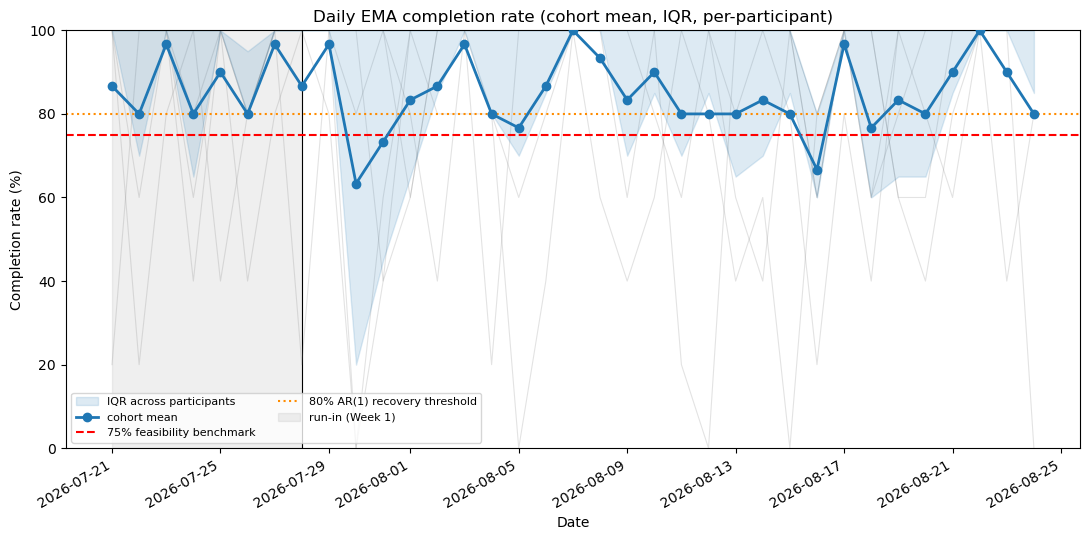

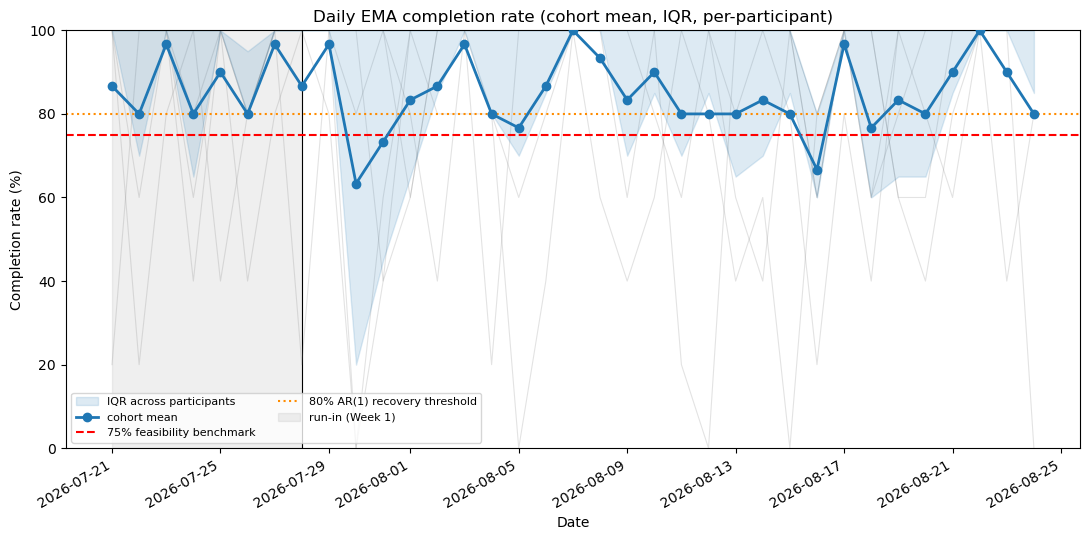

In [6]:
fig = s.plot_ema_completion_over_time(ema_df, user_df)
fig

<!-- interp -->
**Interpretation — Step 4 (EMA completion).** Cohort completion is **≈85%**, clearing the 75% feasibility benchmark; per-participant it ranges **76%–91%**, with **P5 weakest (76%)** and P6 strongest. Median latency ≈33 min sits inside the 60-min window.

*The figure:* bold line = cohort mean, shaded band = participant IQR, faint gray = individual trajectories, red/orange = 75%/80% thresholds, gray span = Week-1 run-in. **Read the spread, not just the mean** — a participant riding near 76% is who a coordinator watches, and a mean dip right after the run-in boundary would signal prompt fatigue once adaptive prompts begin.

## Step 5 — MSSD family
- **Base MSSD** (`compute_mssd`) — the per-series signal the engine rolls.
- **Run-in baseline MSSD** — Week-1 base MSSD used to calibrate each participant's threshold.
- **LT-MSSD** — overall day-to-day volatility (daily means).
- **AR(1)** parameters + within-person eligibility threshold.

The composite B1/B2 per-prompt trigger signal is built with `_prep_trigger_signal`.

In [7]:
signal = s._prep_trigger_signal(item_df, user_df)   # composite B1/B2 per prompt + enrolled_at
print("composite trigger-signal rows:", len(signal))

# Base MSSD demo (matches the notebook definition; NaN pairs dropped)
print("compute_mssd([4,5,3,nan,6]) =", s.compute_mssd(pd.Series([4,5,3,np.nan,6])))

run_in = s.compute_run_in_mssd(signal)              # Week-1 base MSSD
lt     = s.compute_lt_mssd(signal)                  # overall LT-MSSD (daily means)
mssd_table = run_in.merge(lt, on="user_id", how="outer")
print("\nPer-participant run-in (base) MSSD and overall LT-MSSD:")
display(mssd_table)

composite trigger-signal rows: 892
compute_mssd([4,5,3,nan,6]) = 2.5

Per-participant run-in (base) MSSD and overall LT-MSSD:


,user_id,run_in_mssd,lt_mssd
0,1,0.828125,0.317999
1,2,0.515625,0.235185
2,3,0.267241,0.258758
3,4,0.379310,0.167193
4,5,1.470000,0.634373
5,6,0.475000,0.235947


In [8]:
# AR(1) recovery per participant (rho_hat, sigma_hat) on the composite signal
ar_rows = []
for uid, g in signal.sort_values("sent_at").groupby("user_id"):
    rho, sig = s.compute_ar1_parameters(g["value_numeric"])
    ar_rows.append(dict(user_id=uid, rho_hat=round(rho,3), sigma_hat=round(sig,3),
                        expected_mssd=round(s.compute_expected_mssd(sig, rho),3)))
display(pd.DataFrame(ar_rows))

# Within-person eligibility threshold (expanding 80th pct, shifted; no look-ahead)
thr = s.compute_within_person_threshold(signal, quantile=0.80)
print("within-person threshold: non-null values =", int(thr.notna().sum()), "of", len(thr))

,user_id,rho_hat,sigma_hat,expected_mssd
0,1,0.216,0.668,0.700
1,2,0.323,0.593,0.476
2,3,0.659,0.584,0.232
3,4,0.186,0.493,0.395
4,5,0.261,0.878,1.140
5,6,0.428,0.686,0.538


within-person threshold: non-null values = 868 of 892


<!-- interp -->
**Interpretation — Step 5 (MSSD family).** This is the core of *who gets intervened*. **Run-in MSSD** (Week-1 volatility) calibrates each person's threshold; **LT-MSSD** captures day-to-day swings; **AR(1) ρ̂/σ̂** give the theoretical expected MSSD. **P5 is the volatility outlier** (run-in ≈1.47, σ̂ ≈0.88, expected MSSD ≈1.14); **P3/P4 are the calmest** (expected ≈0.23–0.40). Because the threshold is *within-person*, calm participants aren't penalized — each is judged against their own baseline. The first few prompts per person have no threshold yet (needs ≥3 history points).

## Step 6 — Wearable / wear-time (benchmark ≥ 8 h/day, ≥ 5 days/week)

In [9]:
wear = s.compute_wear_time(hr_df)
print("wear-time rows (user-day):", len(wear))
print("mean wear h/day:", round(float((wear['wear_minutes']/60).mean()), 2))
display(wear.head())
print("wear gaps (>2h) detected:", len(s.identify_wear_gaps(hr_df)))

wear-time rows (user-day): 210
mean wear h/day: 9.65


,user_id,date,wear_minutes,wear_pct
0,1,2026-07-21,645.0,76.785714
1,1,2026-07-22,645.0,76.785714
2,1,2026-07-23,645.0,76.785714
3,1,2026-07-24,165.0,19.642857
4,1,2026-07-25,645.0,76.785714


wear gaps (>2h) detected: 210


<!-- interp -->
**Interpretation — Step 6 (Wear time).** Mean **≈9.6 h/day**, above the 8 h goal. But the per-day rows expose bad days (e.g. a ≈20% low-wear day) that the mean hides — the wear-time heatmap in Step 15 makes these visible per participant.

## Step 7 — JITAI decision audit (two-stage: eligibility → randomization)
Kept strictly separate per PI sign-off (p = 0.50, cooldown 60 min, cap 4/day).

In [10]:
print("Decision-stage audit (per participant + ALL):")
display(s.audit_decision_stages(jitai_df))

cd = s.check_cooldown_compliance(jitai_df)
cap = s.check_daily_cap_compliance(jitai_df)
print("cooldown violations:", int(cd['violation'].sum()) if len(cd) else 0,
      "| daily-cap violations:", int(cap['exceeds_cap'].sum()) if len(cap) else 0)

dose = s.compute_intervention_dosage(
    jitai_df.drop(columns=['enrolled_at'], errors='ignore')
            .merge(user_df[['user_id','enrolled_at']], on='user_id', how='left'))
print("mean dosage on active days:",
      round(float(dose.loc[dose['is_active_phase'],'prompts_sent'].mean()), 2) if len(dose) else float('nan'))

Decision-stage audit (per participant + ALL):


,user_id,total_decision_points,eligible,randomized_to_send,sent,not_sent,pct_sent_of_eligible
0,1,476,469,235,135,341,28.784648
1,2,489,199,92,85,404,42.713568
2,3,502,3,1,1,501,33.333333
3,4,493,18,6,6,487,33.333333
4,5,509,506,257,137,372,27.075099
5,6,479,197,99,80,399,40.609137
6,ALL,2948,1392,690,444,2504,31.896552


cooldown violations: 0 | daily-cap violations: 0
mean dosage on active days: 3.18


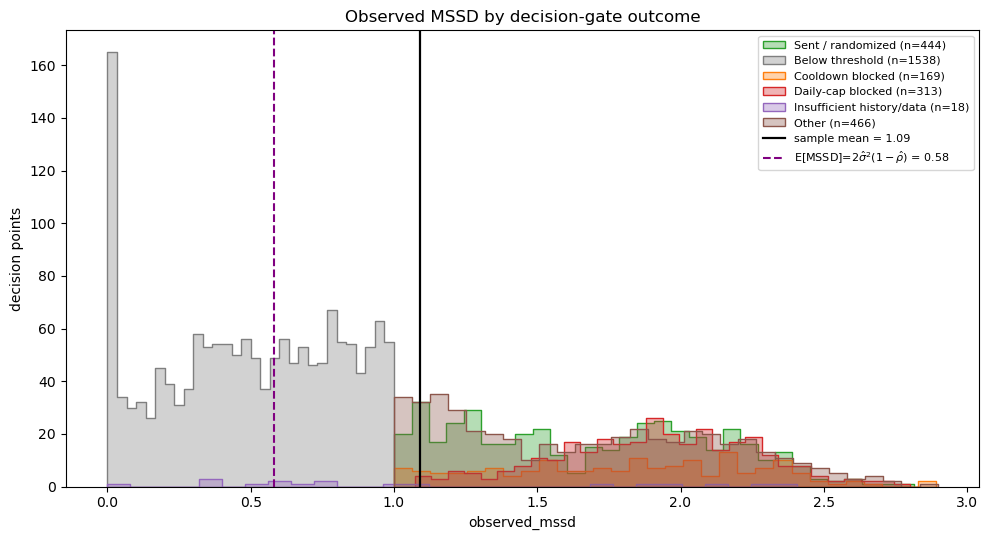

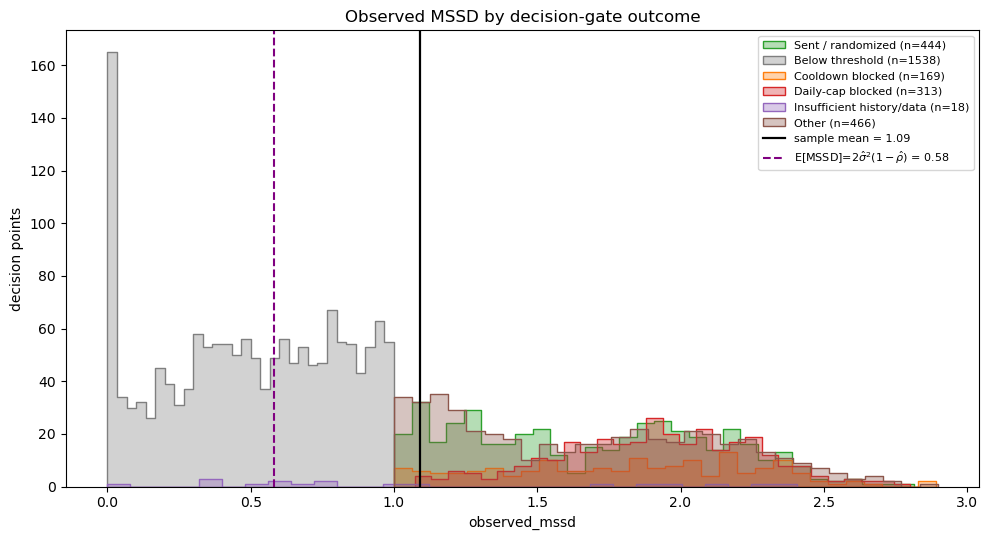

In [11]:
fig = s.plot_mssd_distribution(jitai_df, item_df=item_df)
fig

<!-- interp -->
**Interpretation — Step 7 (Decision audit).** The two-stage gate, kept strictly separate: cohort **2948 decision points → 1392 eligible → 690 randomized → 444 sent** (≈32% sent-of-eligible, consistent with the p=0.5 coin flip minus cooldown/cap losses). **0 cooldown and 0 cap violations.** The per-participant contrast is the whole story: **P5 eligible 506×, P3 only 3×**.

*The figure:* `observed_mssd` colored by decision gate. Most mass is "below threshold" (people usually aren't volatile); the *sent* bars sit in the high-MSSD tail — the engine fires on genuine volatility, not noise.

## Step 8 — Push delivery funnel + latency

,stage,count,pct_of_sent
0,sent,444,100.000000
1,accepted_by_expo,444,100.000000
2,received_on_device,407,91.666667
3,receipt_reported,369,83.108108


median end-to-end pipeline (s): 5.0


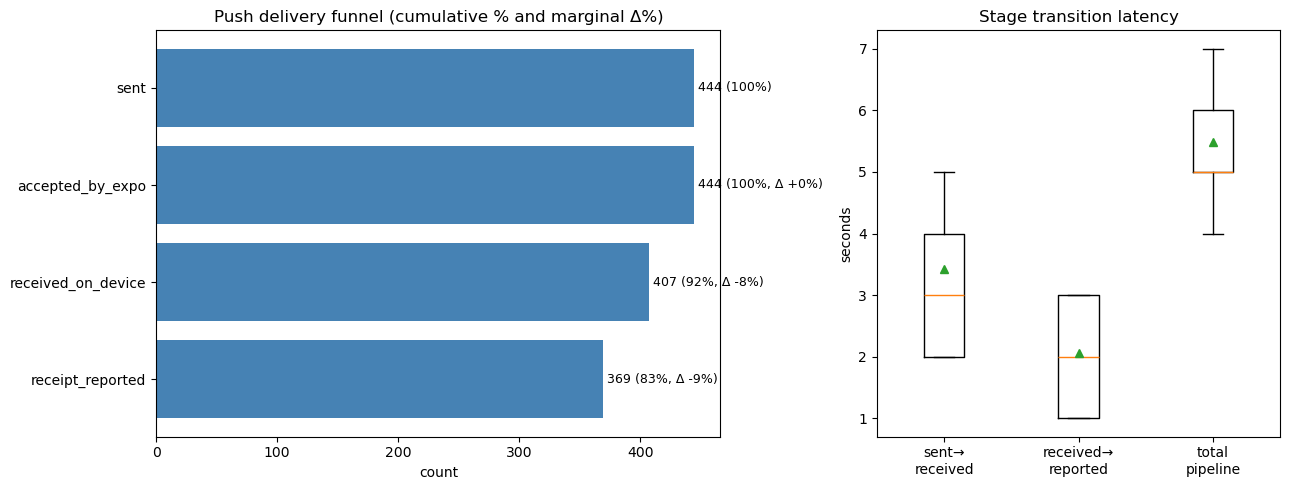

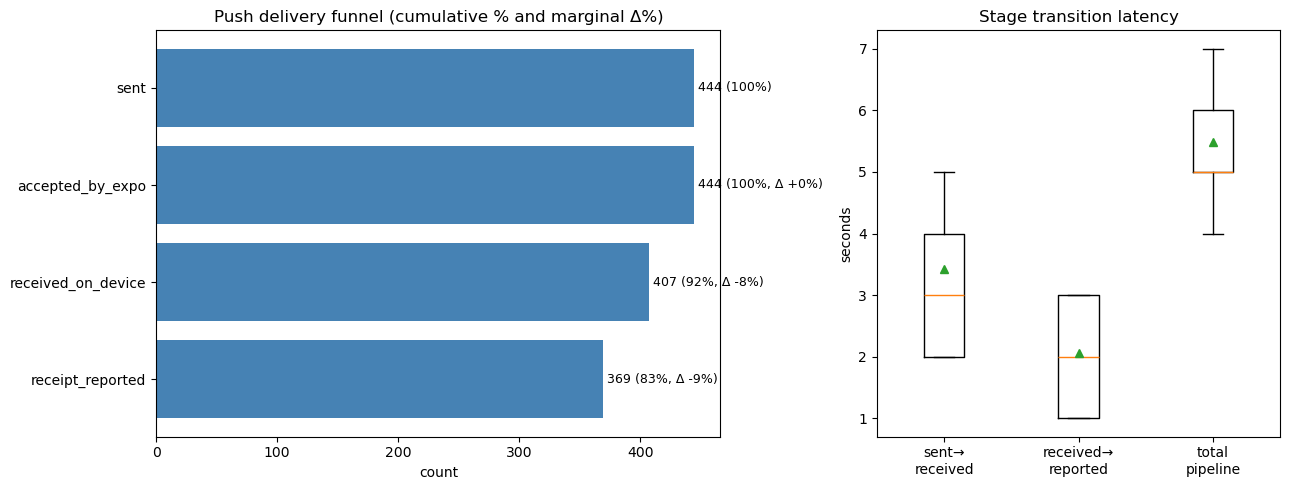

In [12]:
display(s.compute_delivery_funnel(jitai_df))
pl = s.compute_push_latency(jitai_df)
print("median end-to-end pipeline (s):", round(float(pl['total_pipeline_sec'].median()), 2))
fig = s.plot_delivery_funnel(jitai_df)
fig

<!-- interp -->
**Interpretation — Step 8 (Delivery funnel).** 444 sent → 444 accepted by Expo → **407 received (92%)** → 369 receipt-reported (83%); median pipeline ≈5 s. *The figure's* marginal Δ% shows the biggest loss is **device receipt (−8%)** — the classic background-sync problem where the push leaves the server but never buzzes the phone. For a participant this is the gap between "the engine decided to help" and "help actually arrived."

## Step 9 — Engagement

In [13]:
display(s.compute_engagement_rates(eng_df, jitai_df))
ol = s.compute_open_latency(eng_df, jitai_df)
print("median open latency (min):", round(float(ol.median()), 1) if len(ol) else float('nan'))

,user_id,delivered,opened,acted,dismissed,open_rate_pct,act_rate_pct,dismiss_rate_pct
0,1,123,123,0,0,100.0,0.0,0.0
1,2,83,83,0,0,100.0,0.0,0.0
2,3,1,1,0,0,100.0,0.0,0.0
3,4,6,6,0,0,100.0,0.0,0.0
4,5,125,125,0,0,100.0,0.0,0.0
5,6,69,69,0,0,100.0,0.0,0.0
6,ALL,407,407,0,0,100.0,0.0,0.0


median open latency (min): 10.1


<!-- interp -->
**Interpretation — Step 9 (Engagement).** ⚠️ **Synthetic artifact:** the mock generator only emits `ema_opened`, so open=100% and act/dismiss=0% for everyone. Against real data this shows opened < delivered and a real acted/dismissed split — i.e., whether delivered prompts are actually engaged with.

## Step 10 — Retention & dropout

In [14]:
ret = s.compute_retention(user_df)
print("retention:", {k: (round(v,1) if isinstance(v,float) else v) for k,v in ret.items()})
print("\nDropout classification:")
display(s.classify_dropout(user_df, ema_df))

retention: {'overall_n': 6, 'retained_n': 5, 'overall_retention_pct': 83.3, 'run_in_retained_n': 5, 'run_in_retention_pct': 83.3, 'active_retained_n': 5, 'active_retention_pct': 83.3}

Dropout classification:


,user_id,classification,last_active_date,days_since_active
0,1,active,2026-08-24,0
1,2,active,2026-08-24,0
2,3,active,2026-08-24,0
3,4,active,2026-08-24,0
4,5,active,2026-08-23,1
5,6,formal_withdrawal,2026-08-24,0


<!-- interp -->
**Interpretation — Step 10 (Retention).** **83% retained (5/6)**. **P6 is a formal withdrawal** (`is_enrolled=False`); P5 missed a recent day but is still active. The key move is separating *withdrawal* (left the study) from *non-response* (missing prompts ≠ dropout) — this protects the denominator in every other metric.

## Step 11 — HR ↔ EMA volatility concordance

In [15]:
conc = s.compute_hr_ema_concordance(hr_df, signal)
display(conc)

,user_id,pearson_r,p_value,n_paired_observations
0,1,0.055890,0.556549,113
1,2,-0.080805,0.408013,107
2,3,-0.094941,0.326095,109
3,4,-0.083439,0.381762,112
4,5,0.106270,0.297654,98
5,6,0.074562,0.420293,119


<!-- interp -->
**Interpretation — Step 11 (HR–EMA concordance).** ⚠️ **Synthetic artifact:** mock HR is generated independently of EMA, so all r ≈ 0 (p > 0.05) — the expected null. With real Garmin data, a positive per-participant r would mean physiological arousal and self-reported volatility agree, evidence the biometric signal could complement (or substitute for) EMA-based triggering.

## Step 12 — Overall study report
`build_study_report()` bundles every cohort-level table. (If the DB was reachable in Step 1 this
is already computed; otherwise we build it now on synthetic data.)

In [16]:
if study_report is None:
    study_report = s.build_study_report()

print("Feasibility scorecard (cohort):")
scorecard = pd.DataFrame([study_report['feasibility']]).T.rename(columns={0: 'value'})
display(scorecard)

print("\nPer-participant LT-MSSD:")
display(study_report['lt_mssd_per_user'])

Feasibility scorecard (cohort):


,value
ema_response_rate_pct,84.952381
wear_time_mean_hrs_per_day,9.645238
wear_time_days_meeting_goal,181.000000
retention_pct,83.333333
intervention_dosage_mean_per_day,3.178571
cooldown_violation_count,0.000000
daily_cap_violation_count,0.000000
delivery_funnel_received_pct,91.666667
run_in_mssd_mean,0.655884
overall_lt_mssd_mean,0.308242



Per-participant LT-MSSD:


,user_id,lt_mssd
0,1,0.317999
1,2,0.235185
2,3,0.258758
3,4,0.167193
4,5,0.634373
5,6,0.235947


In [17]:
# Export the scorecard exactly as the pipeline would (single-row CSV)
out_dir = Path("output"); out_dir.mkdir(exist_ok=True)
s.export_feasibility_report(study_report['feasibility'], str(out_dir / "study_feasibility.csv"))
print("wrote", out_dir / "study_feasibility.csv")

wrote output/study_feasibility.csv


<!-- interp -->
**Interpretation — Step 12 (Study scorecard).** The go/no-go table in one row: response ≈85%, wear ≈9.6 h, retention 83%, dosage ≈3.2 prompts/active-day (< the cap of 4), 0 rule violations, 92% delivery. Every preregistered benchmark in one place, exported to CSV for the PI. Per-participant LT-MSSD again flags **P5** as the cohort's volatility outlier.

## Step 13 — Per-participant report
`build_participant_report(uid)` returns the same metrics sliced to one participant, plus that
participant's **rolling `observed_mssd` trajectory** (read from `JITAILog`) and their run-in /
LT-MSSD.

In [18]:
uid = int(user_df['user_id'].iloc[0])
rpt = s.build_participant_report(uid)

print(f"Participant {uid}")
print("  run-in MSSD (base):", round(rpt['run_in_mssd'],3) if pd.notna(rpt['run_in_mssd']) else 'n/a',
      "| LT-MSSD:", round(rpt['lt_mssd'],3) if pd.notna(rpt['lt_mssd']) else 'n/a',
      "| dropout:", rpt['dropout_status'])
print("  median latency (min):", round(rpt['median_latency_min'],1) if pd.notna(rpt['median_latency_min']) else 'n/a',
      "| wear h/day:", round(rpt['wear_mean_hrs_per_day'],2) if pd.notna(rpt['wear_mean_hrs_per_day']) else 'n/a',
      "| cooldown violations:", rpt['cooldown_violations'])
print("\nEMA response (ALL row):"); display(rpt['ema_response_rate'])
print("Decision stages:"); display(rpt['decision_stages'])
print("Rolling observed_mssd trajectory (from JITAILog):")
display(rpt['mssd_trajectory'].head(10))

Participant 1
  run-in MSSD (base): 0.828 | LT-MSSD: 0.318 | dropout: active
  median latency (min): 35.0 | wear h/day: 10.06 | cooldown violations: 0

EMA response (ALL row):


,user_id,delivered,completed,response_rate_pct
1,ALL,175,148,84.571429


Decision stages:


,user_id,total_decision_points,eligible,randomized_to_send,sent,not_sent,pct_sent_of_eligible
1,ALL,476,469,235,135,341,28.784648


Rolling observed_mssd trajectory (from JITAILog):


,triggered_at,observed_mssd,send_prompt,trigger_reason
0,2026-07-21 09:00:00+00:00,1.883326,False,insufficient within-person history
1,2026-07-21 10:00:00+00:00,1.757121,False,insufficient within-person history
2,2026-07-21 13:00:00+00:00,2.003733,False,insufficient within-person history
3,2026-07-21 14:00:00+00:00,1.953025,False,"eligible, not randomized"
4,2026-07-21 15:00:00+00:00,1.383735,False,"eligible, not randomized"
5,2026-07-21 15:30:00+00:00,1.370728,True,prompt sent
6,2026-07-21 16:00:00+00:00,1.647544,False,cooldown active
7,2026-07-21 16:30:00+00:00,2.316240,False,"eligible, not randomized"
8,2026-07-21 17:00:00+00:00,1.965639,False,"eligible, not randomized"
9,2026-07-21 20:00:00+00:00,1.745211,False,"eligible, not randomized"


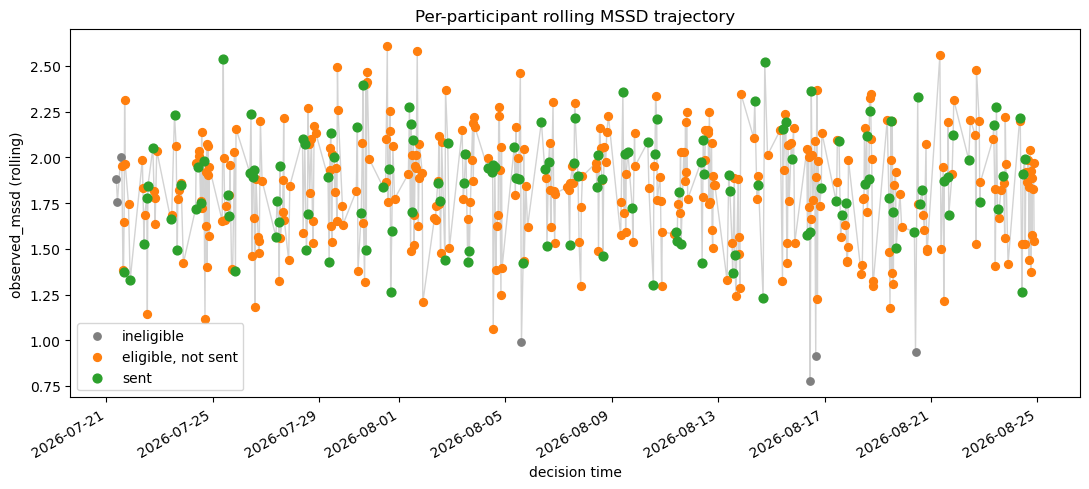

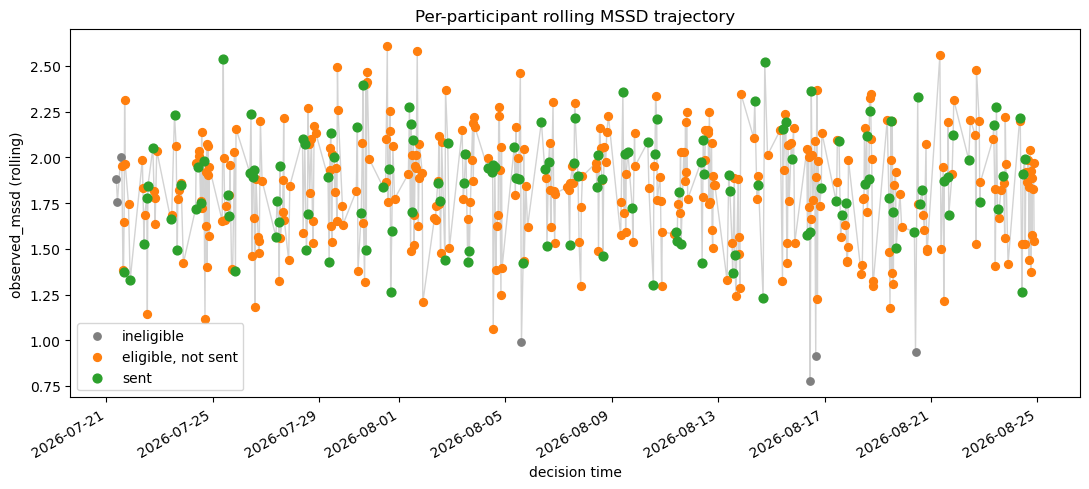

In [19]:
# Rolling observed_mssd trajectory for this participant (read from JITAILog).
s.plot_participant_mssd_trajectory(s.load_jitai_log(user_id=uid))

<!-- interp -->
**Interpretation — Step 13 (Per-participant report).** The same metrics sliced to one participant, plus the rolling `observed_mssd` trajectory read straight from `JITAILog`. *The figure* lets you watch volatility rise, cross threshold, and get randomized — colored sent / eligible-not-sent / ineligible. This is the view a coordinator reviews before a check-in visit.

## Step 14 — Moderation framework *(synthetic demo)*
Tier-1/2/3 moderation needs Qualtrics baseline + biomarker frames that are not in the operational
DB, so this step always uses a small synthetic demo to show the `compute_tier*` interface.

In [20]:
rng = np.random.default_rng(0)
n = 40
outcomes = pd.DataFrame(dict(user_id=range(n), outcome_domain=["eating"]*n,
                             outcome_value=rng.normal(size=n),
                             treatment_indicator=[0,1]*(n//2)))
mods1 = pd.DataFrame(dict(user_id=range(n),
    supps_p=rng.normal(size=n), ders_16=rng.normal(size=n), tfeq_r18=rng.normal(size=n),
    dmq_r=rng.normal(size=n), maia_2=rng.normal(size=n)))
print("Tier 1 (confirmatory) moderation:")
display(s.compute_tier1_moderation(outcomes, mods1))

mods3 = pd.DataFrame(dict(user_id=range(n),
    macarthur_ladder=rng.normal(size=n), everyday_discrimination=rng.normal(size=n),
    rmeq_score=rng.normal(size=n)))
print("Tier 3 (exploratory) moderation with Bonferroni:")
display(s.compute_tier3_exploratory(outcomes, mods3))

Tier 1 (confirmatory) moderation:


,moderator,interaction_estimate,se,p_value,ci_lower,ci_upper
0,supps_p,-0.257273,0.232819,0.276476,-0.729452,0.214906
1,ders_16,-0.338868,0.269445,0.216614,-0.885327,0.207591
2,tfeq_r18,0.110822,0.258694,0.670919,-0.413834,0.635479
3,dmq_r,-0.131295,0.263804,0.621722,-0.666315,0.403724
4,maia_2,0.092920,0.222536,0.678754,-0.358403,0.544244


Tier 3 (exploratory) moderation with Bonferroni:


,moderator,interaction_estimate,se,p_value,ci_lower,ci_upper,bonferroni_corrected_p
0,macarthur_ladder,0.541159,0.218362,0.018026,0.098301,0.984017,0.054079
1,everyday_discrimination,0.037064,0.248926,0.882466,-0.467781,0.541909,1.000000
2,rmeq_score,0.026320,0.292988,0.928919,-0.567887,0.620526,1.000000


<!-- interp -->
**Interpretation — Step 14 (Moderation).** ⚠️ **Synthetic/random by design** — the demo moderators are noise, so Tier-1 effects are all non-significant. It does correctly demonstrate the **multiple-comparison guard**: a Tier-3 term (`macarthur_ladder`) is "significant" raw (p≈0.02) but **evaporates after Bonferroni (≈0.05)** — exactly the trap exploratory analyses must avoid.

## Step 15 — Feasibility figures (cohort)

Report-ready figures for each preregistered feasibility dimension. Benchmark reference lines: EMA ≥ 75%, wear ≥ 8 h/day, response window 60 min, daily cap 4.

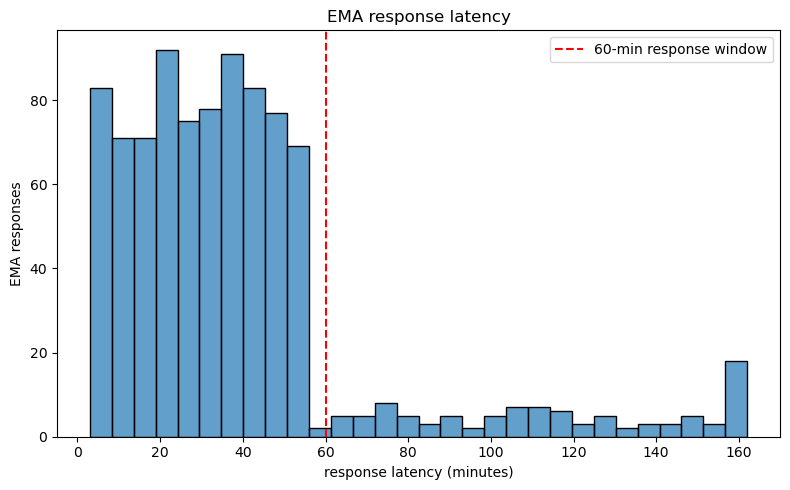

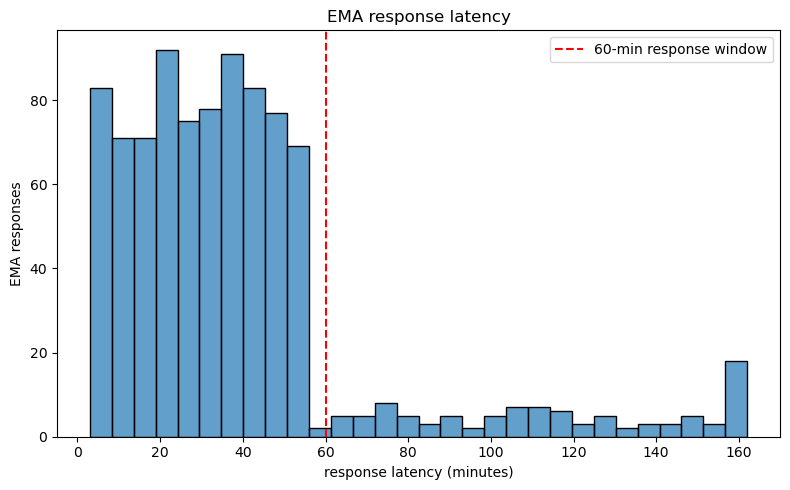

In [21]:
s.plot_response_latency(ema_df)

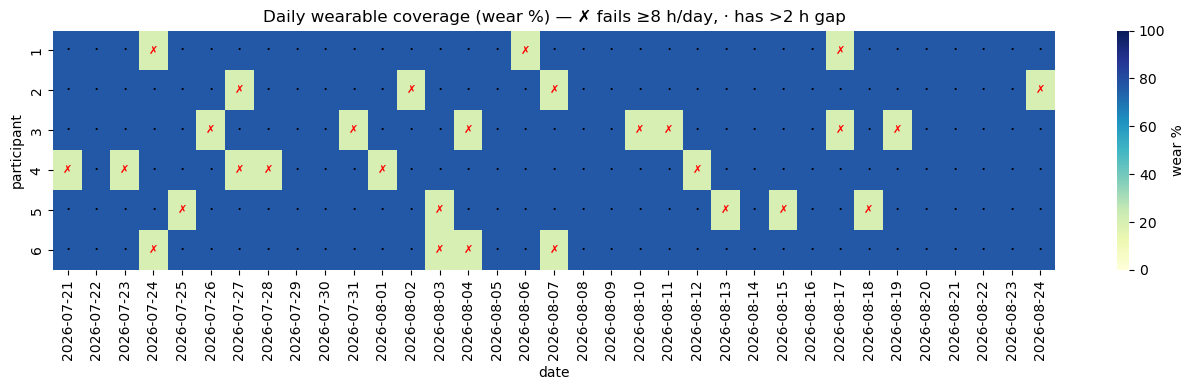

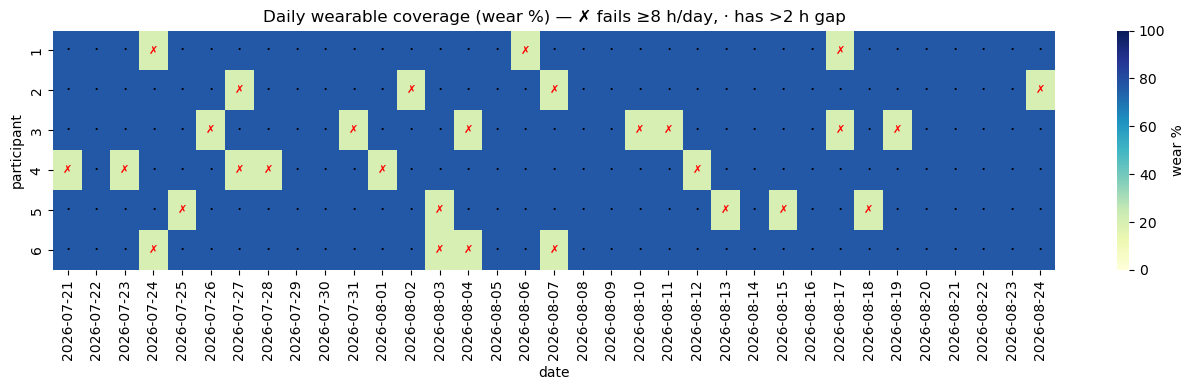

In [22]:
s.plot_wear_time_heatmap(hr_df)

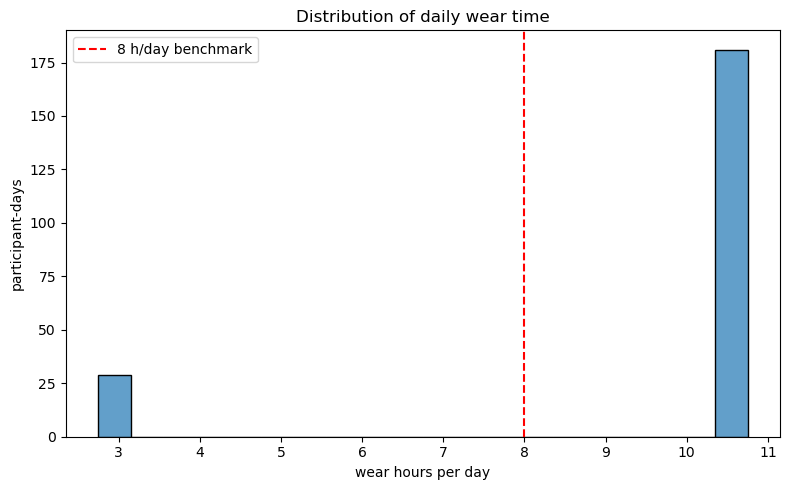

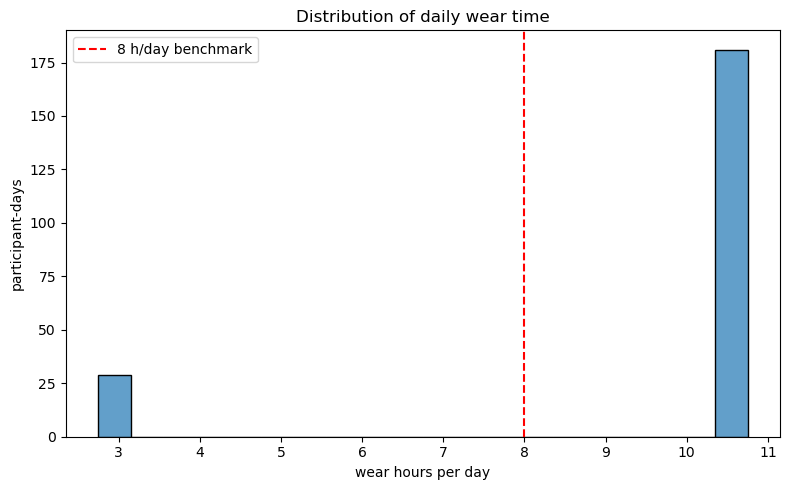

In [23]:
s.plot_wear_hours_distribution(hr_df)

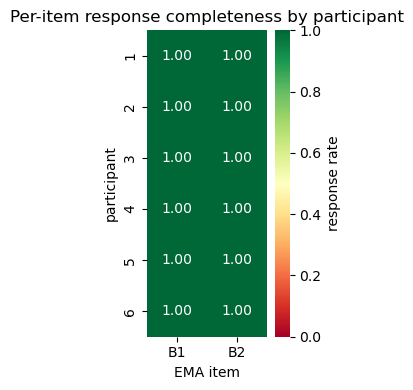

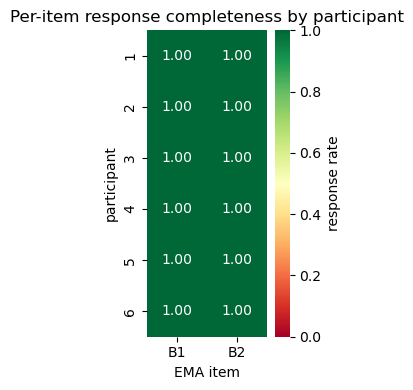

In [24]:
s.plot_bitem_missingness(item_df)

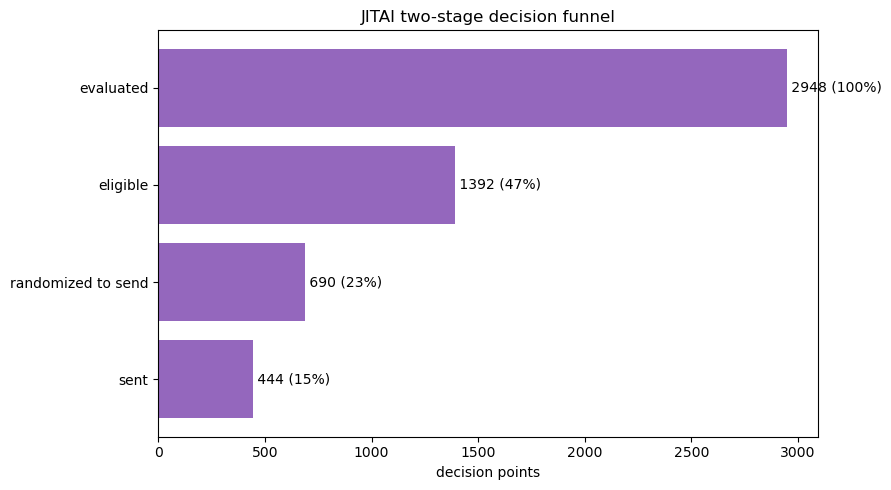

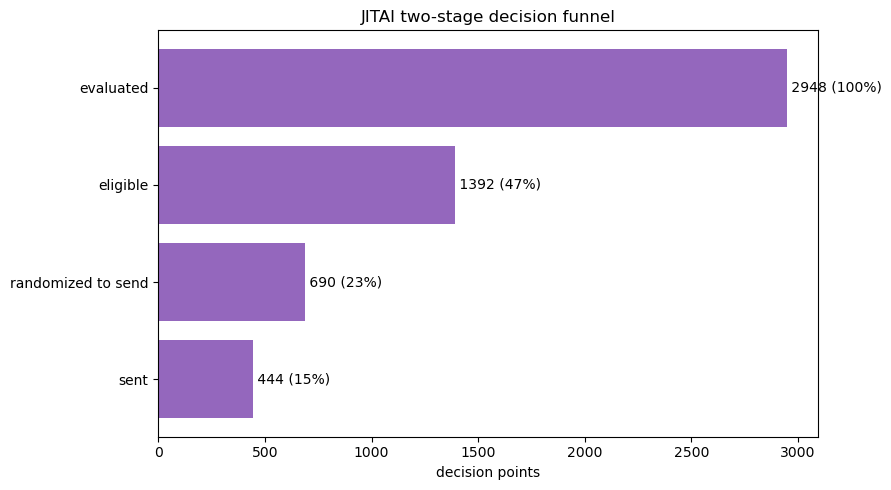

In [25]:
s.plot_decision_funnel(jitai_df)

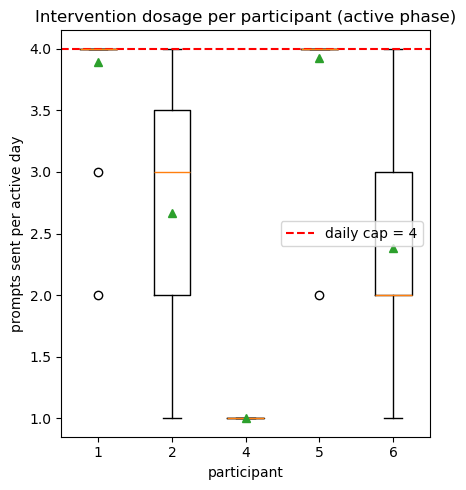

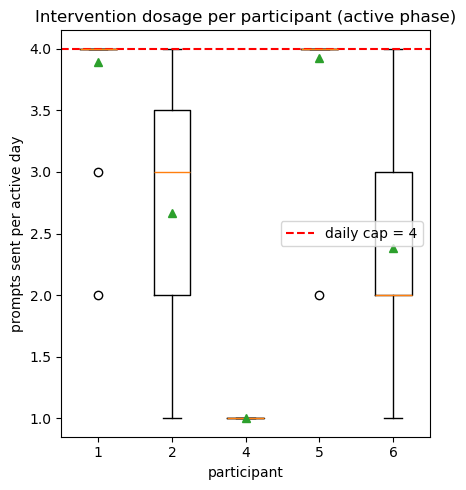

In [26]:
s.plot_intervention_dosage(jitai_df, user_df)

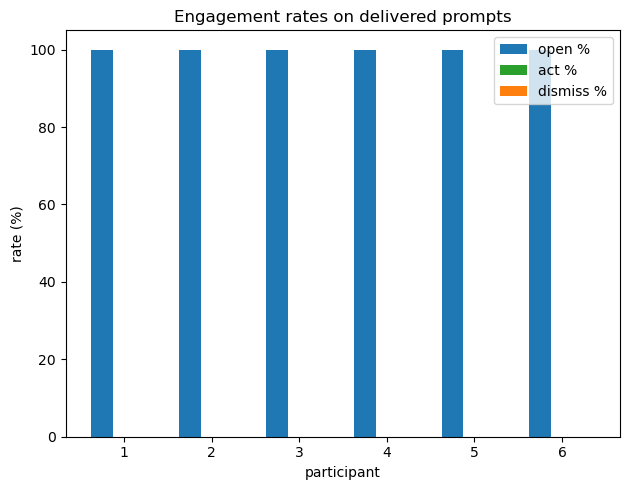

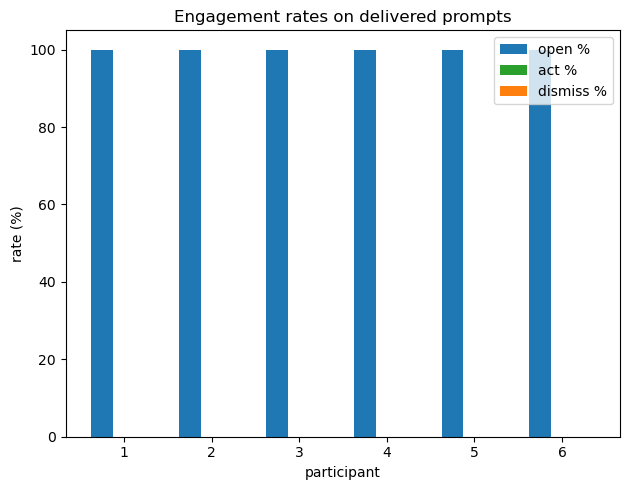

In [27]:
s.plot_engagement_rates(eng_df, jitai_df)

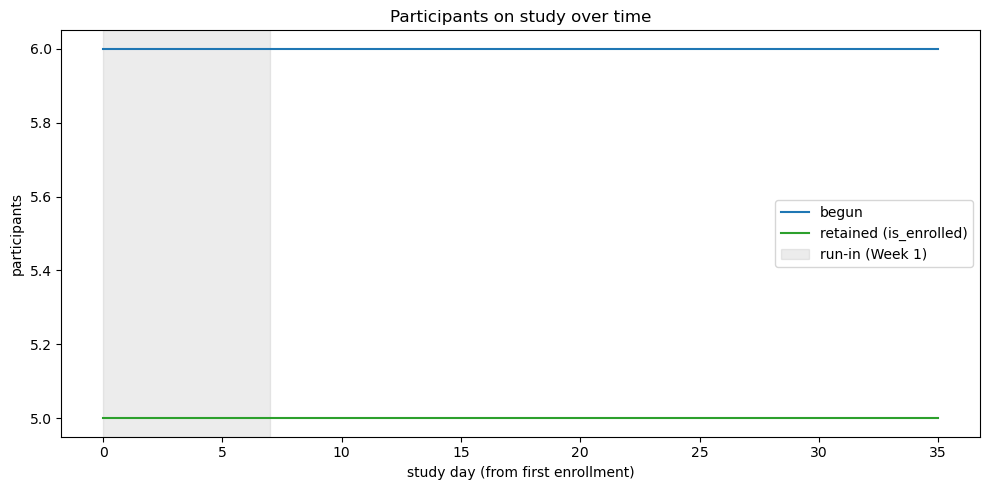

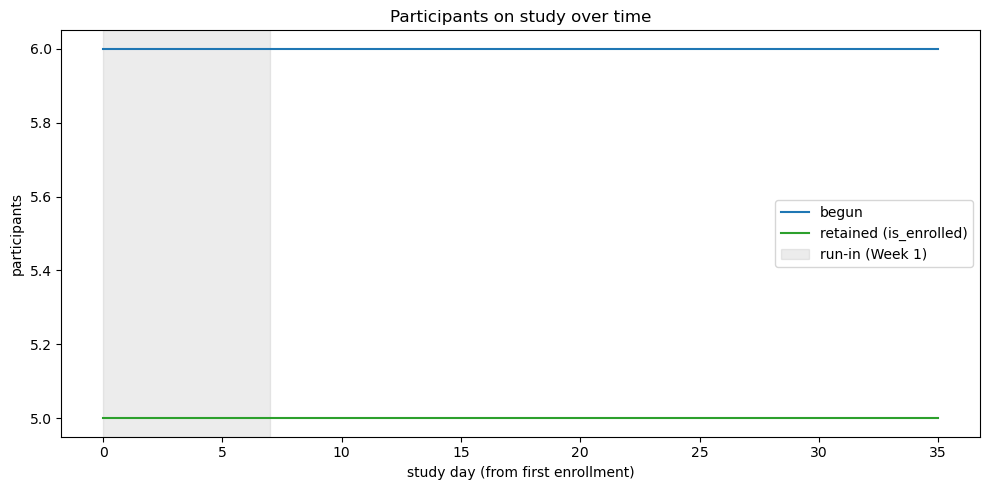

In [28]:
s.plot_retention_curve(user_df)

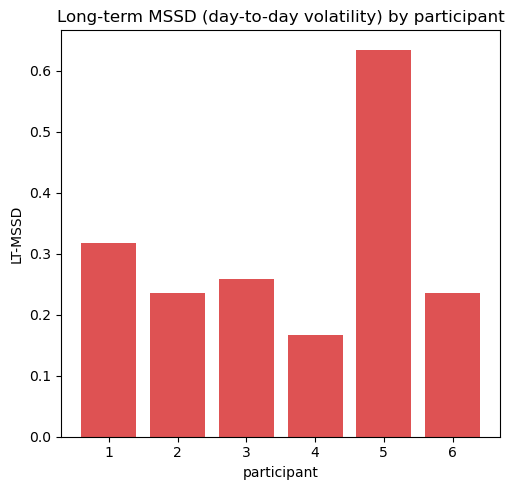

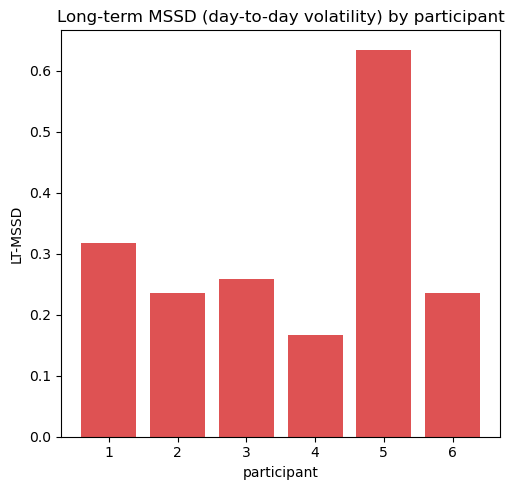

In [29]:
s.plot_lt_mssd_by_participant(signal)

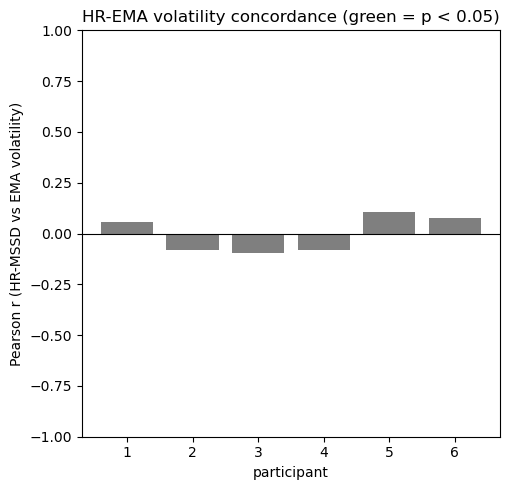

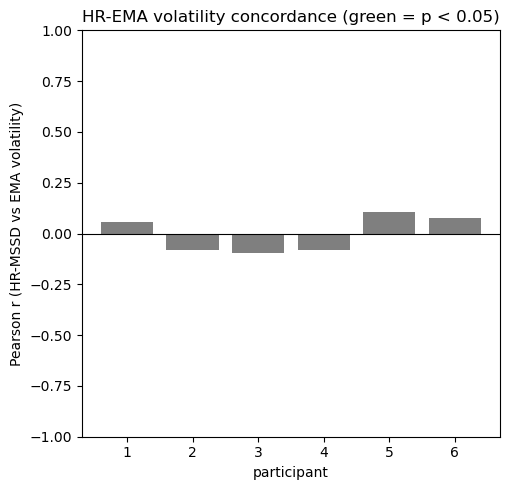

In [30]:
s.plot_hr_ema_concordance(hr_df, signal)

<!-- interp -->
**Interpretation — Step 15 (Cohort figure gallery).** Report-ready views of each feasibility dimension: **response-latency** vs the 60-min line; **wear-time heatmap** (participant × day; `✗`=fails 8 h, `·`=has a >2 h gap) — the fastest way to spot chronic non-wearers vs one-off bad days; **wear-hours distribution**; **B-item completeness** for the B1/B2 trigger items specifically; the **two-stage decision funnel**; **intervention dosage** per participant vs the cap (P5 dosed heavily, P3 barely); **engagement**, **retention curve**, **LT-MSSD ranking**, and **HR–EMA concordance**. Nearly every figure is faceted per participant because **the between-participant variance is where the signal lives.**

### Additional decomposed / stratified figures

EMA disposition decomposition, per-participant MSSD facets, OS/app-state delivery stratification, and the JITAI decision-rule timeline.

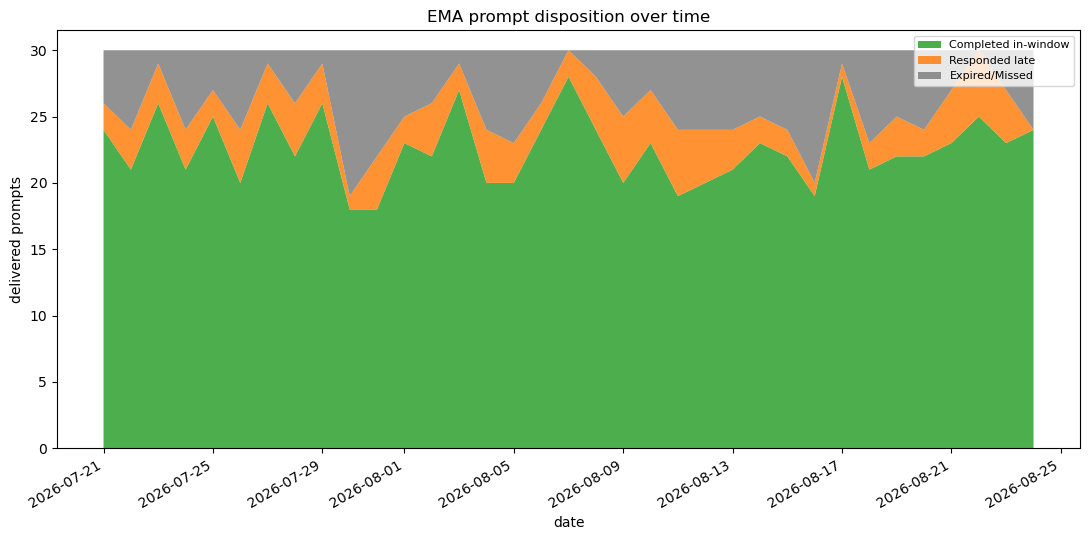

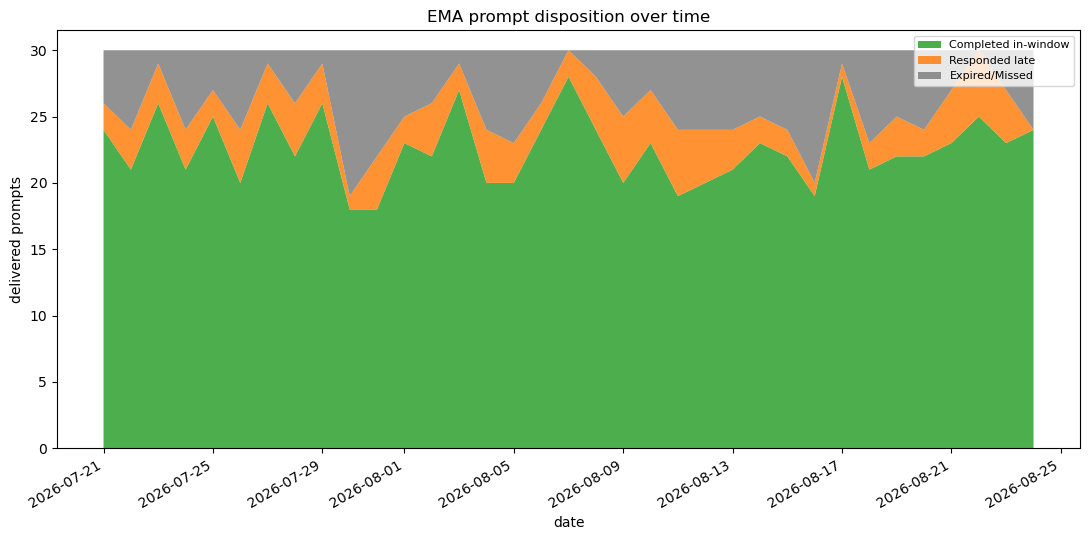

In [31]:
s.plot_ema_disposition_over_time(ema_df)

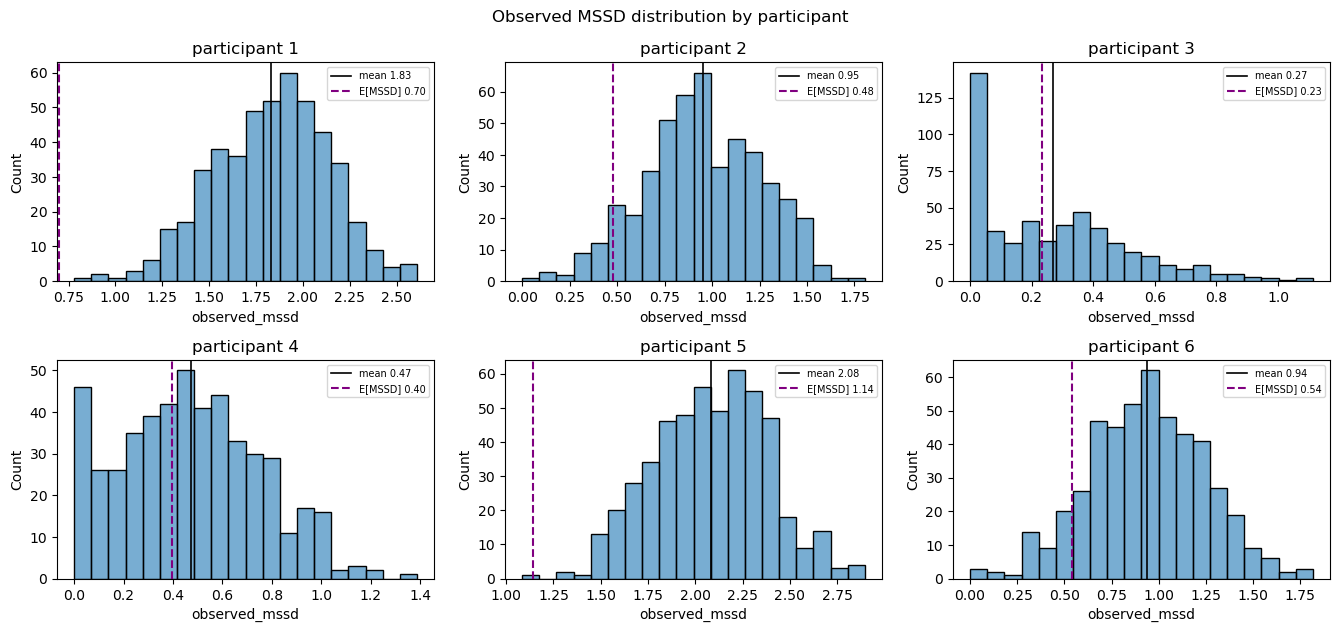

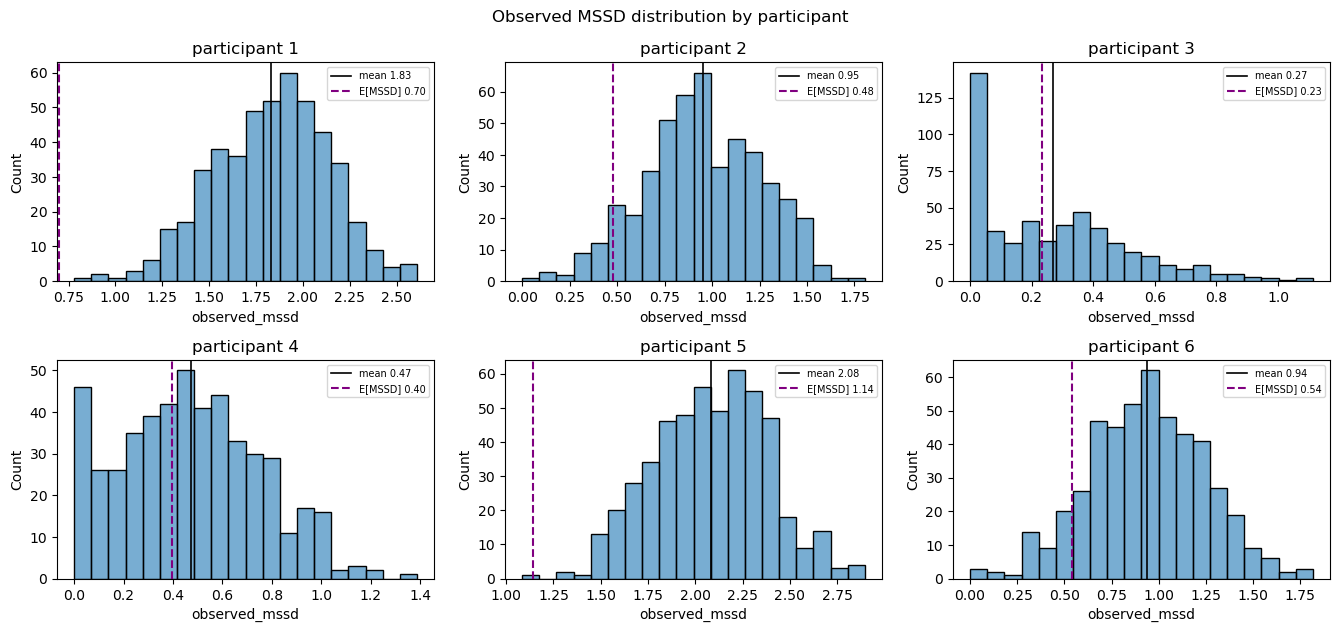

In [32]:
s.plot_mssd_distribution_by_participant(jitai_df, item_df=item_df)

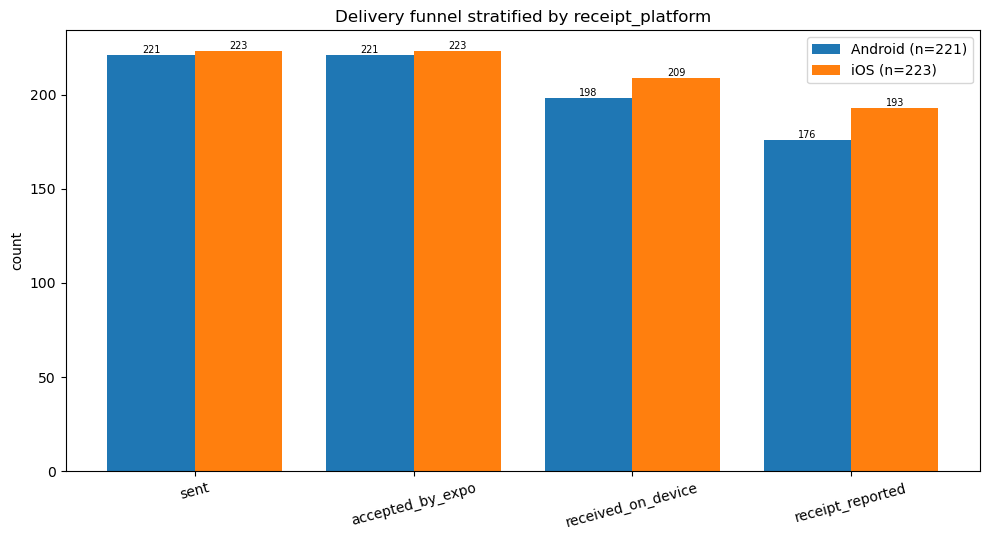

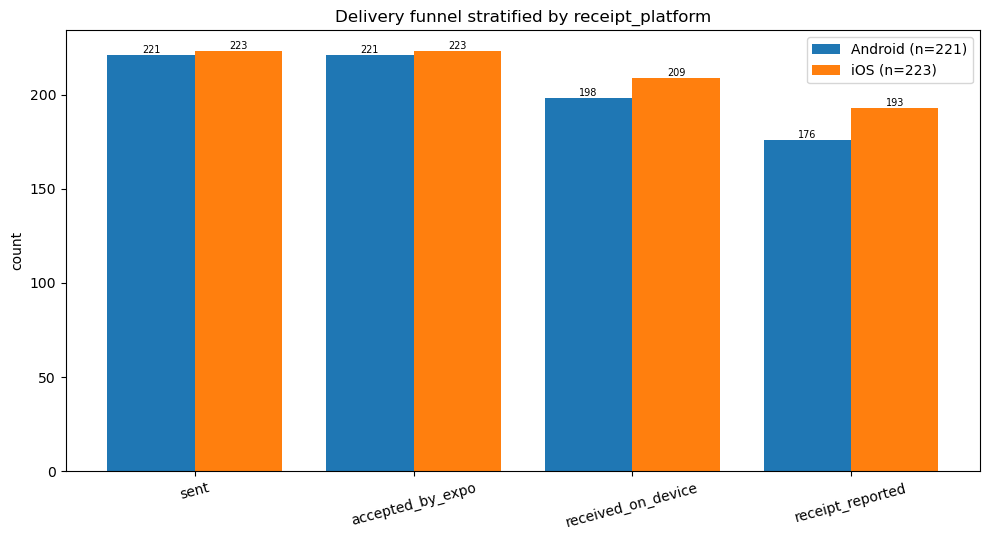

In [33]:
s.plot_delivery_funnel_stratified(jitai_df, by="receipt_platform")

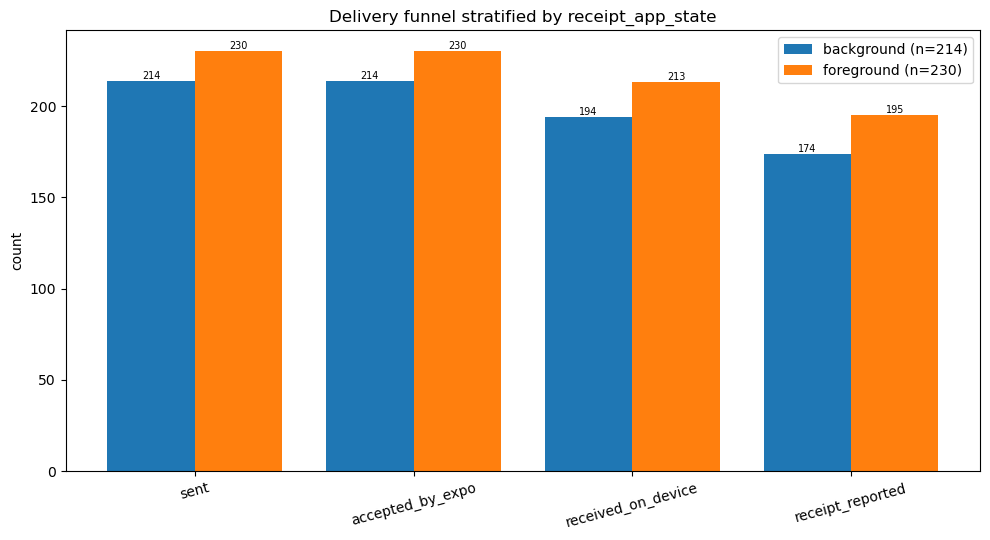

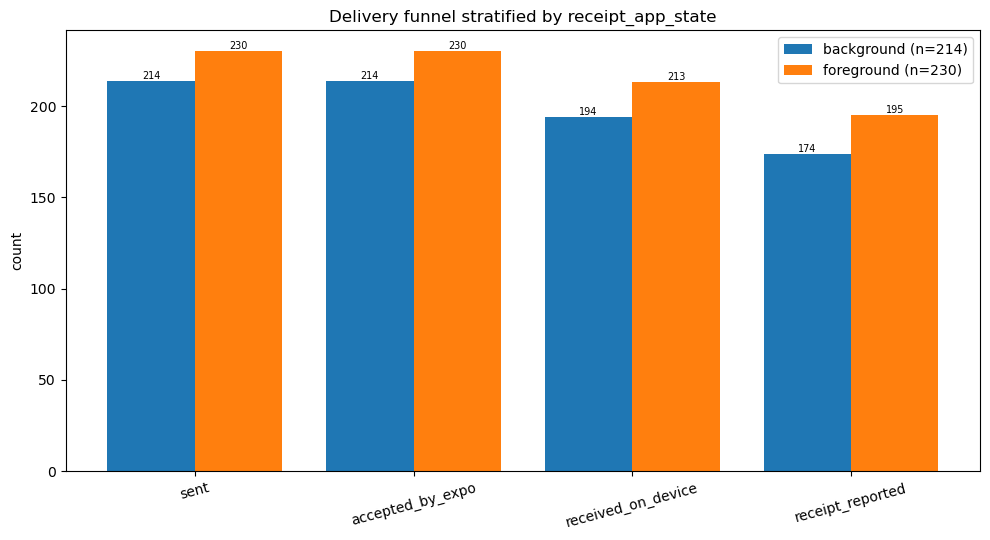

In [34]:
s.plot_delivery_funnel_stratified(jitai_df, by="receipt_app_state")

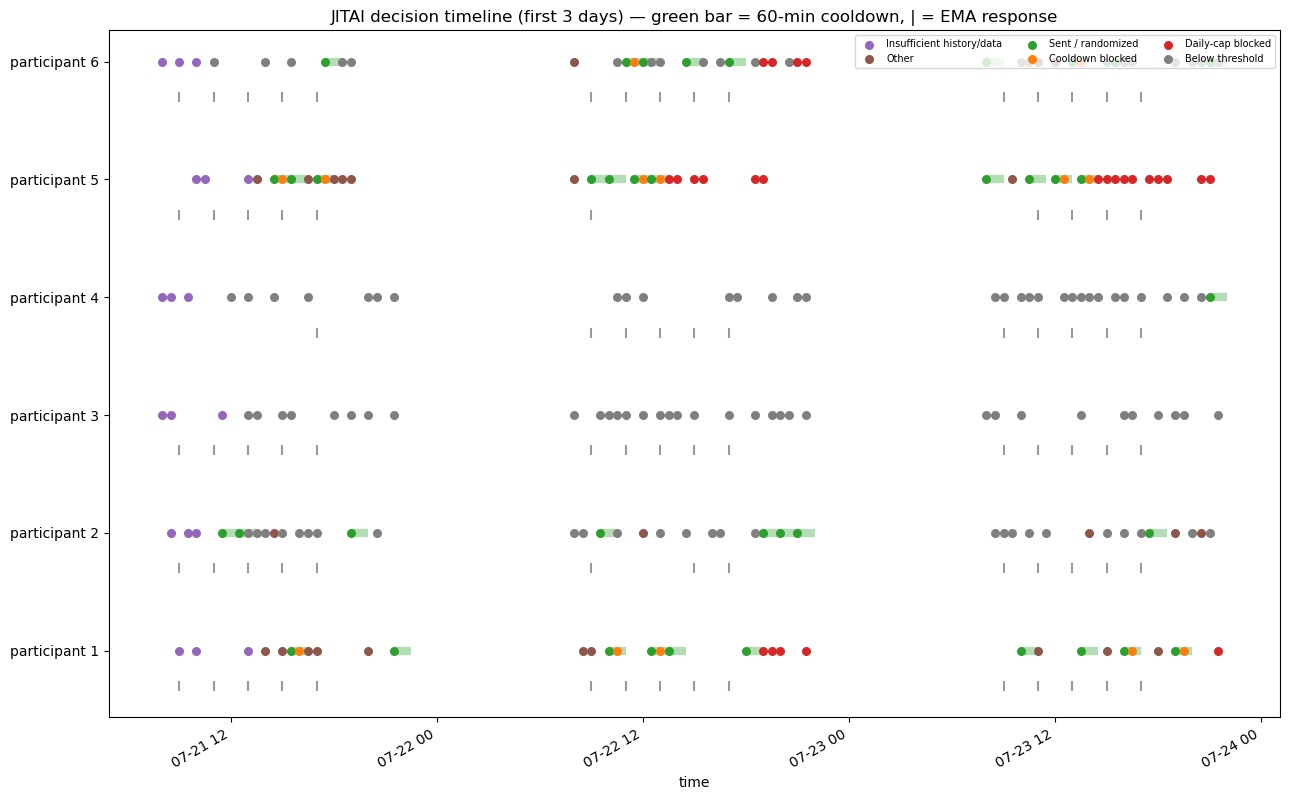

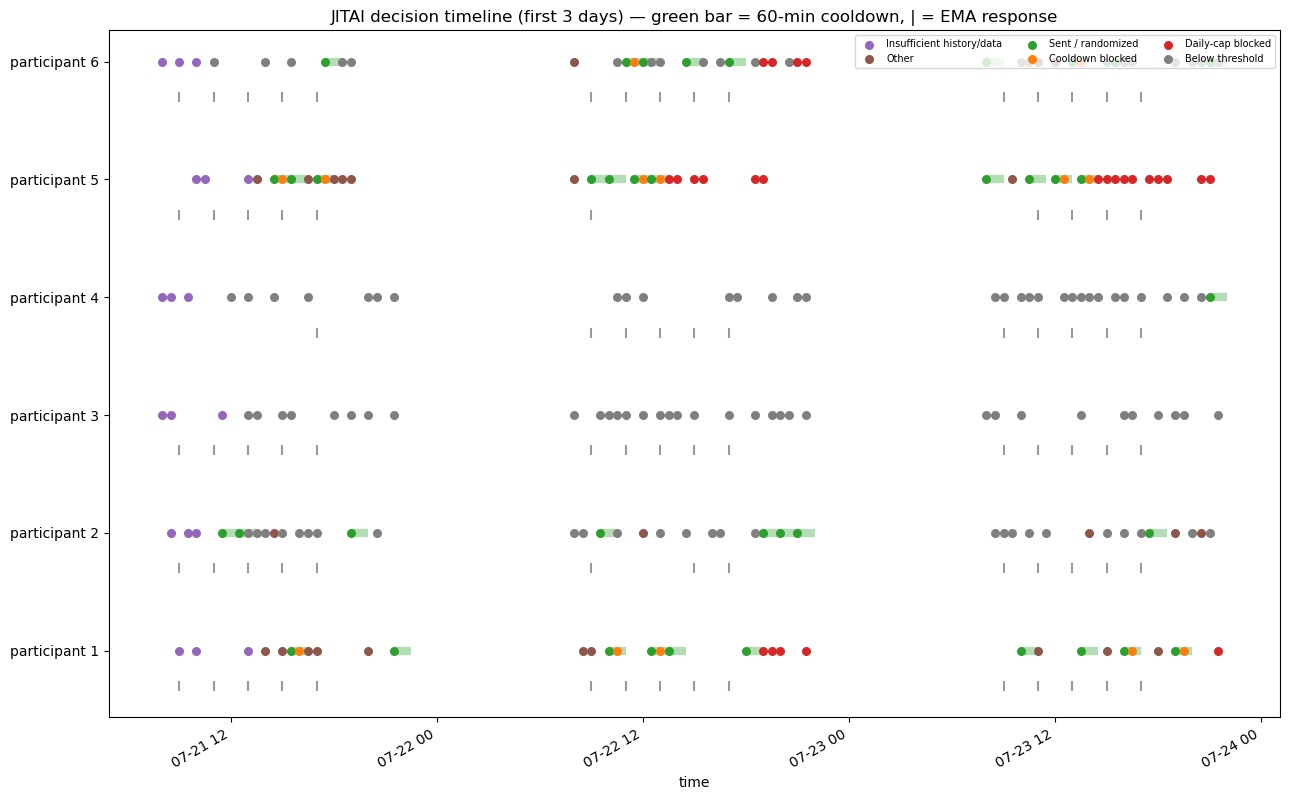

In [35]:
s.plot_jitai_decision_timeline(jitai_df, ema_df, day_window=3)

<!-- interp -->
**Interpretation — Additional decomposed / stratified figures.**
- **EMA disposition** — stacks each day's prompts into completed-in-window / responded-late / expired-missed, showing *how* non-response happens, not just that it does.
- **MSSD facets** — per-participant histograms with each person's mean and expected-MSSD line; a visual threshold-calibration check.
- **Delivery funnel by platform / app-state** — isolates whether iOS vs Android or foreground vs background loses pushes (the background-sync question).
- **Decision timeline** — a per-participant swimlane with 60-min cooldown buffers and EMA ticks, visually confirming the decision rules are enforced.

**The participant story overall.** The cohort resolves into archetypes: **P5** = volatile, heavily-dosed, and (not coincidentally) lowest EMA response — the person JITAI is built for and the one at risk of fatigue; **P3/P4** = stable, rarely eligible, correctly seldom prompted; **P6** = withdrawn; **P1** = the representative middling participant in the per-participant report. The notebook moves from *"did the study run?"* (response, wear, delivery, retention — all pass) to *"did the adaptive logic behave?"* (two-stage funnel, 0 violations, dosage under cap) to *"who is each participant?"* (within-person MSSD, dosage, trajectory) — and the recurring lesson is that **cohort means pass, but the per-participant spread is what matters.**

---
### Notes
- To run against the **real database**, set `SECRET_KEY` and `DATABASE_URL` (or the
  `DATABASE_*` vars) in the environment before launching Jupyter, then re-run from Step 1 —
  every step will use live rows and the synthetic fallback is skipped.
- `observed_mssd` is the engine's **rolling** trigger signal (authoritative, from `JITAILog`);
  the study/participant **overall** volatility is **LT-MSSD** (daily-mean successive differences).
